In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(42)

Create a 3×3 tensor filled with random values between 0 and 1 and normalize it so all entries sum to 1.

In [2]:
tensor = torch.rand(3, 3)

normalized_tensor = tensor / tensor.sum()

print("Original Tensor:")
print(tensor)

print("\nNormalized Tensor:")
print(normalized_tensor)

print("\nSum:", normalized_tensor.sum())

Original Tensor:
tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009],
        [0.2566, 0.7936, 0.9408]])

Normalized Tensor:
tensor([[0.1441, 0.1495, 0.0625],
        [0.1567, 0.0638, 0.0982],
        [0.0419, 0.1296, 0.1537]])

Sum: tensor(1.)


Reshape a 1D tensor of length 16 into a 4×4 matrix, then flatt

In [4]:
tensor = torch.arange(16)

matrix = tensor.reshape(4, 4)

flattened = matrix.flatten()

print("Original:")
print(tensor)

print("\n4x4 Matrix:")
print(matrix)

print("\nFlattened:")
print(flattened)

Original:
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])

4x4 Matrix:
tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11],
        [12, 13, 14, 15]])

Flattened:
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])


Multiply tensors of size 3×4 and 4×2.

In [5]:
A = torch.rand(3, 4)
B = torch.rand(4, 2)

C = torch.matmul(A, B)

print("Shape of A:", A.shape)
print("Shape of B:", B.shape)
print("Shape of Result:", C.shape)

print(C)

Shape of A: torch.Size([3, 4])
Shape of B: torch.Size([4, 2])
Shape of Result: torch.Size([3, 2])
tensor([[1.1694, 0.8267],
        [1.1592, 0.8852],
        [0.6979, 0.5712]])


f(x)=x²+3x and compute gradient at x=2.


In [6]:
x = torch.tensor(2.0, requires_grad=True)

f = x**2 + 3*x

f.backward()

print("f(x) =", f.item())
print("Gradient =", x.grad.item())

f(x) = 10.0
Gradient = 7.0


Stop gradient tracking using torch.no_grad().


In [7]:
x = torch.tensor([2.0], requires_grad=True)

y = x * 3

with torch.no_grad():
    z = y * 2

w = y + 1

w.backward()

print("x.grad =", x.grad)
print("z requires grad =", z.requires_grad)

x.grad = tensor([3.])
z requires grad = False


Implement MAE manually and compare with nn.L1Loss.


In [8]:
y_true = torch.tensor([1.0, 2.0, 3.0])
y_pred = torch.tensor([1.5, 2.5, 2.0])

# Manual MAE
mae_manual = torch.mean(torch.abs(y_true - y_pred))

# Built-in MAE
criterion = nn.L1Loss()
mae_builtin = criterion(y_pred, y_true)

print("Manual MAE :", mae_manual.item())
print("Built-in MAE :", mae_builtin.item())

Manual MAE : 0.6666666865348816
Built-in MAE : 0.6666666865348816


Train linear regression on synthetic data.


In [9]:
# Synthetic Data
X = torch.unsqueeze(torch.linspace(0, 10, 100), dim=1)

y = 2*X + 1 + torch.randn_like(X)*0.5

# Model
model = nn.Linear(1,1)

criterion = nn.MSELoss()

optimizer = optim.SGD(model.parameters(), lr=0.01)

epochs = 200

for epoch in range(epochs):

    pred = model(X)

    loss = criterion(pred, y)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

print("Weight:", model.weight.item())
print("Bias:", model.bias.item())

Weight: 2.0235331058502197
Bias: 0.8309913873672485


Demonstrate forward pass, loss, backward pass, optimizer step.


In [10]:
model = nn.Linear(1, 1)

criterion = nn.MSELoss()

optimizer = optim.SGD(model.parameters(), lr=0.01)

for epoch in range(100):

    # Forward pass
    output = model(X)

    # Loss
    loss = criterion(output, y)

    # Backward pass
    optimizer.zero_grad()

    loss.backward()

    # Update weights
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch} Loss = {loss.item():.4f}")

Epoch 0 Loss = 48.8013
Epoch 10 Loss = 0.2273
Epoch 20 Loss = 0.2262
Epoch 30 Loss = 0.2251
Epoch 40 Loss = 0.2241
Epoch 50 Loss = 0.2232
Epoch 60 Loss = 0.2225
Epoch 70 Loss = 0.2217
Epoch 80 Loss = 0.2211
Epoch 90 Loss = 0.2205


Train same model using SGD and Adam.


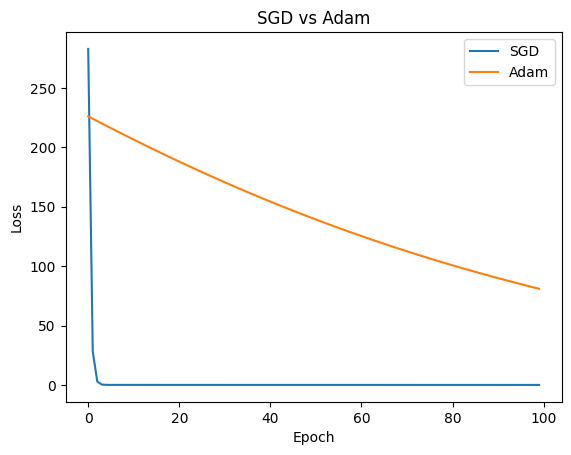

In [11]:
X = torch.unsqueeze(torch.linspace(0, 10, 100), dim=1)
y = 2*X + 1

sgd_model = nn.Linear(1,1)
adam_model = nn.Linear(1,1)

criterion = nn.MSELoss()

sgd = optim.SGD(sgd_model.parameters(), lr=0.01)
adam = optim.Adam(adam_model.parameters(), lr=0.01)

sgd_losses = []
adam_losses = []

for epoch in range(100):

    # SGD
    sgd_pred = sgd_model(X)
    sgd_loss = criterion(sgd_pred, y)

    sgd.zero_grad()
    sgd_loss.backward()
    sgd.step()

    sgd_losses.append(sgd_loss.item())

    # Adam
    adam_pred = adam_model(X)
    adam_loss = criterion(adam_pred, y)

    adam.zero_grad()
    adam_loss.backward()
    adam.step()

    adam_losses.append(adam_loss.item())

plt.plot(sgd_losses, label='SGD')
plt.plot(adam_losses, label='Adam')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SGD vs Adam")

plt.legend()
plt.show()

Implement AND, OR and XOR Gates using Neural Networks

In [13]:
# DATA

X = torch.tensor([
    [0.,0.],
    [0.,1.],
    [1.,0.],
    [1.,1.]
])

y_and = torch.tensor([
    [0.],
    [0.],
    [0.],
    [1.]
])

In [ ]:
# AND Gate 
model = nn.Sequential(
    nn.Linear(2,1),
    nn.Sigmoid()
)

criterion = nn.BCELoss()

optimizer = optim.SGD(model.parameters(), lr=0.1)

for epoch in range(5000):

    output = model(X)

    loss = criterion(output, y_and)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

print(torch.round(model(X)))

tensor([[0.],
        [0.],
        [0.],
        [1.]], grad_fn=<RoundBackward0>)


In [16]:
# OR Gate 

y_or = torch.tensor([
    [0.],
    [1.],
    [1.],
    [1.]
])

model = nn.Sequential(
    nn.Linear(2,1),
    nn.Sigmoid()
)

optimizer = optim.SGD(model.parameters(), lr=0.1)

for epoch in range(5000):

    output = model(X)

    loss = criterion(output, y_or)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

print(torch.round(model(X)))

tensor([[0.],
        [1.],
        [1.],
        [1.]], grad_fn=<RoundBackward0>)


In [17]:
# XOR GATE

y_xor = torch.tensor([
    [0.],
    [1.],
    [1.],
    [0.]
])

xor_model = nn.Sequential(

    nn.Linear(2,4),

    nn.ReLU(),

    nn.Linear(4,1),

    nn.Sigmoid()
)

criterion = nn.BCELoss()

optimizer = optim.Adam(xor_model.parameters(), lr=0.05)

for epoch in range(5000):

    output = xor_model(X)

    loss = criterion(output, y_xor)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

pred = torch.round(xor_model(X))

print("Predictions:")
print(pred)

Predictions:
tensor([[0.],
        [1.],
        [1.],
        [0.]], grad_fn=<RoundBackward0>)
